# Machine learning through everyday examples
## Can a computer learn to make a useful guess?


In [13]:
from pathlib import Path
import sys

# Supports starting Jupyter from this directory or the repository root.
ROOT = next(
    (
        p
        for p in (Path.cwd(), *Path.cwd().parents)
        if (p / "demo_support").is_dir() and (p / "requirements.txt").exists()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Open this notebook from inside the course repository.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from demo_support import visuals as v

v.setup_style()

from demo_support import bikes

state = bikes.load(ROOT)

## 1 · Make a prediction yourself

Imagine you help run a bike-sharing service. You want enough bikes available when people need them.

**Question:** Which of these days had more rentals? What else would you want to know before guessing?

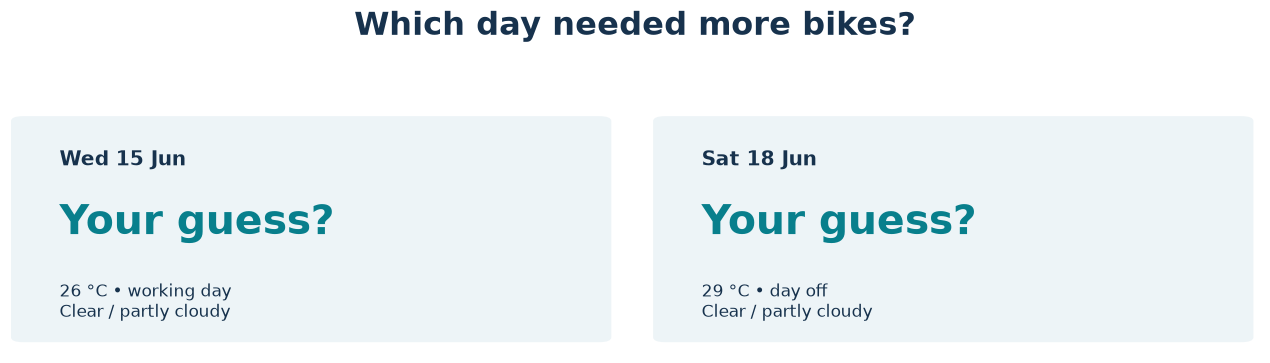

In [3]:
bikes.hook(state)

These are historical days from Capital Bikeshare in Washington, DC.

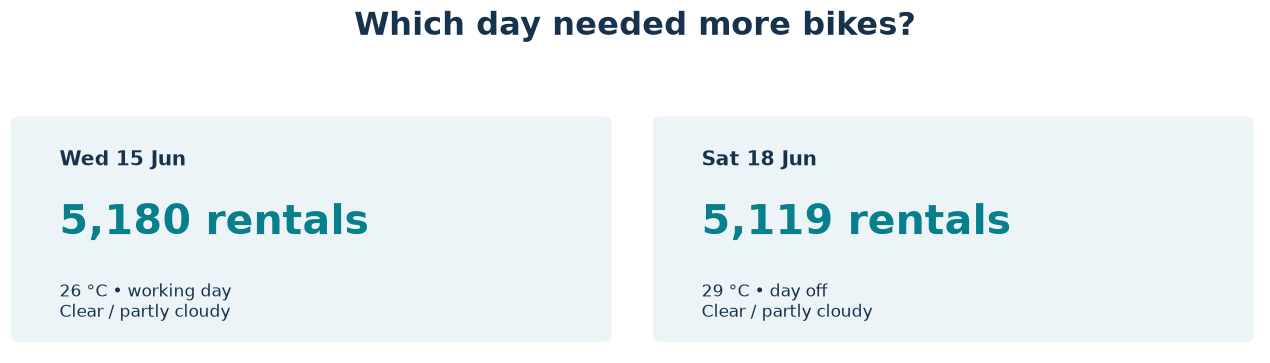

In [4]:
bikes.hook(state, reveal=True)

### Could we just write a rule?

> “If it is warm, expect more rentals.” What might break that rule? Rain? Holidays? Commuters? A special event?

Each dot below is one day. Look for a pattern, then look for exceptions.

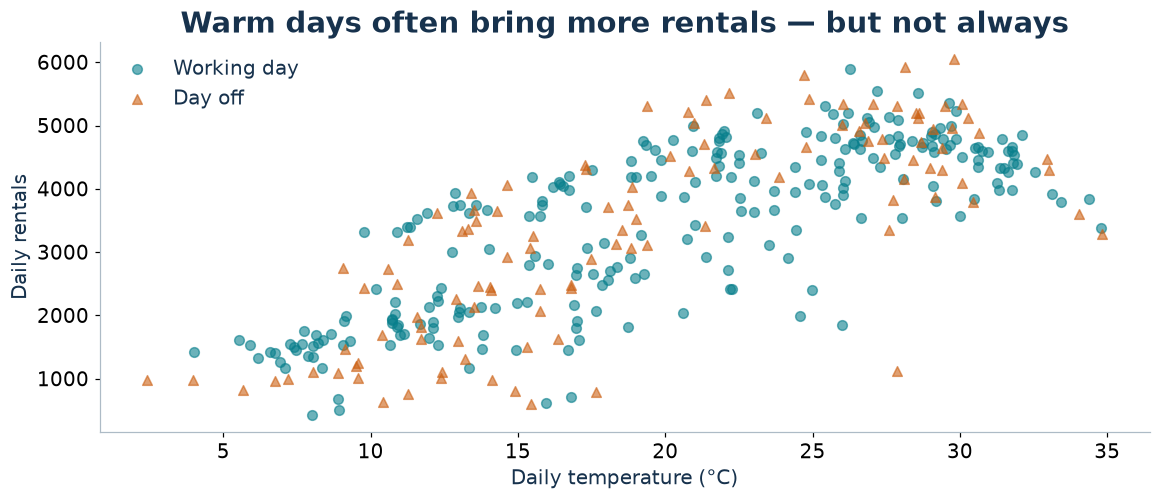

In [5]:
bikes.rules_and_examples(state)

### What machine learning adds
**Machine learning uses examples to learn patterns that help make predictions or decisions in new situations.**

With a handwritten rule, a person specifies how the inputs produce an answer. With supervised machine learning, a person supplies examples of inputs and answers, chooses a learning method, and evaluates the resulting model.

- A **feature** is an input clue, such as temperature or day type.
- A **target** is the answer to predict, such as rental count.
- A **model** is the learned rule used to turn clues into a prediction.

**Question:** Where have you met this idea already? Spam filtering, estimated travel times, and recommendations. Real products may combine multiple methods and human rules.

**Training** means learning from examples. **Prediction** means applying the learned model. Making a prediction does not automatically retrain it.

**Takeaway:** A useful pattern can support a guess without explaining why something happens. The model can also be confidently wrong when a situation is unfamiliar.

## 2 · Three ways to learn

### Supervised: learn from known answers
The computer sees past days **and their rental counts**. It can then make a guess for a different day. Here we reveal one validation example; our final test period stays reserved.

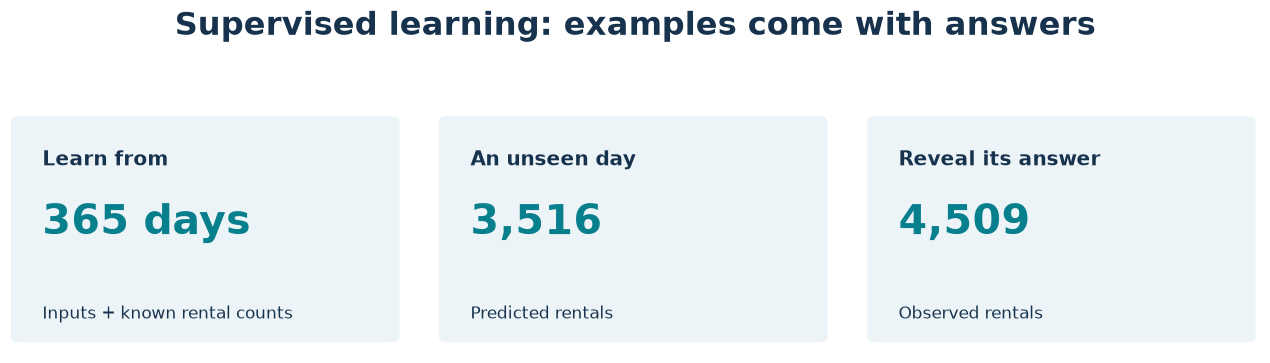

In [6]:
bikes.supervised(state)

A numeric answer is **regression**: how many rentals, how many minutes, what price?

A category is **classification**: spam or useful email, damaged or undamaged package?

**Takeaway:** We learn from examples with known answers. A model can still make a large mistake on an individual example.

### Unsupervised: discover structure
These shoppers are **simulated**, with no preassigned customer categories supplied to the model.

**Question:** Do you see groups before we color them? We compare visits per month and typical basket value. The calculation balances the scales of those two inputs.

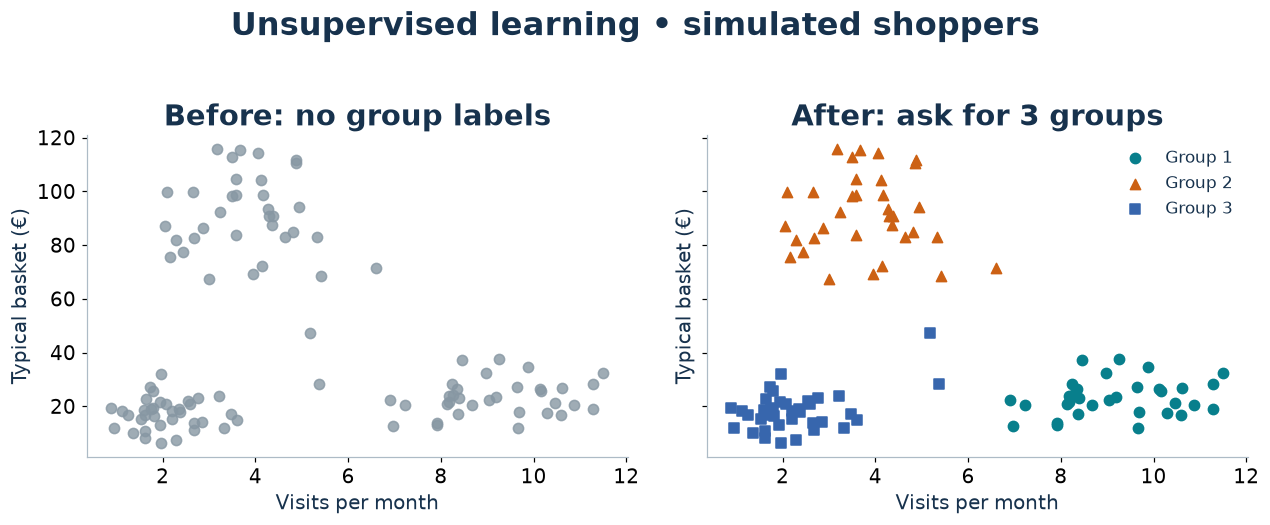

In [7]:
bikes.shoppers(groups=3);

**Discuss:** We might describe a group as “frequent, smaller baskets.” That is our interpretation, not a discovered personality type. The grouping depends on which clues and how many groups we choose.

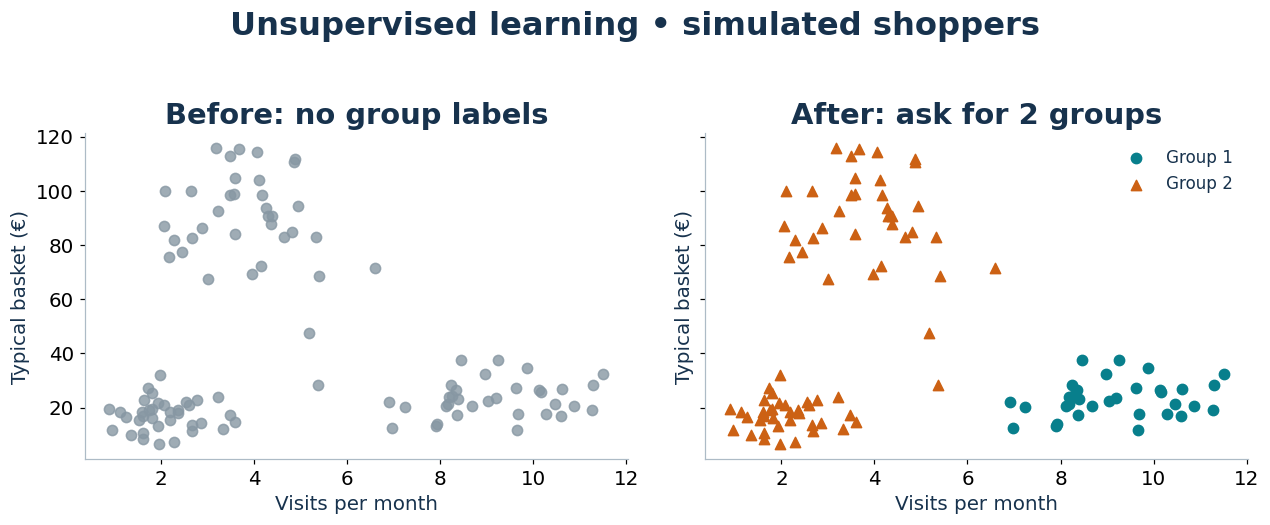

In [8]:
bikes.shoppers(groups=2);

**Takeaway:** Unsupervised learning can reveal structure without known answer labels. It does not guarantee that the groups are meaningful for a business decision.

### Reinforcement: learn through actions and rewards
A simulated robot tries to reach its charging dock. It can move up, right, down, or left. A move changes where it is, so an action affects future options.

It earns **+1** for reaching the dock, pays **0.04** per ordinary move, and pays **0.30** for hitting an obstacle or boundary. Early exploration tries unfamiliar actions. The robot gradually learns which actions lead to better total reward.


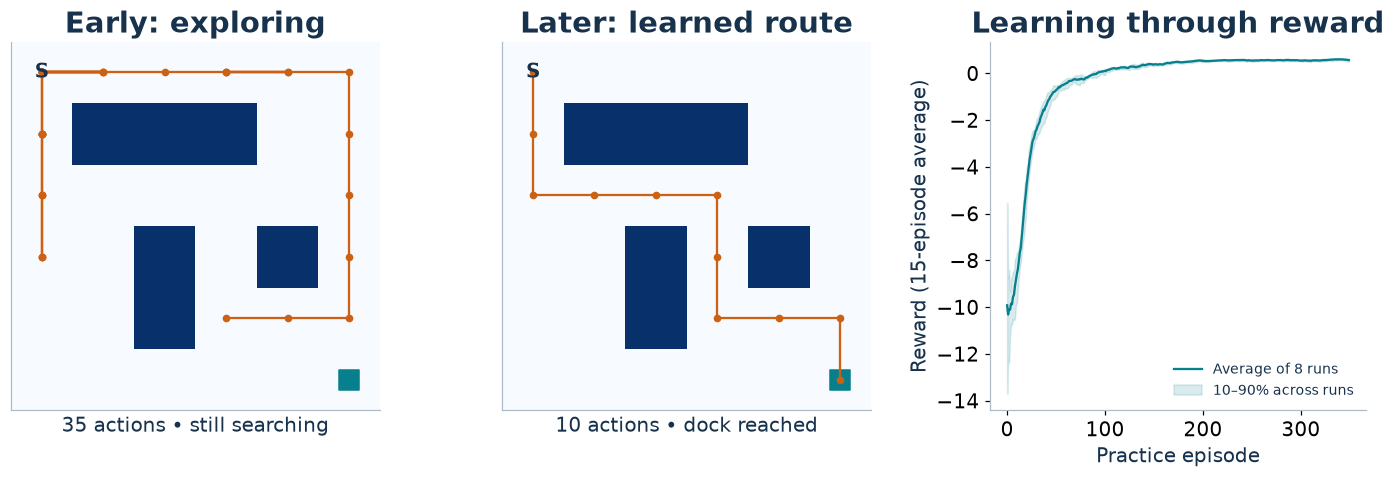

In [8]:
robot_results = bikes.robot()

The route comes from actual tabular Q-learning in this small simulated world. The reward chart summarizes eight independent training runs; individual episodes do not improve smoothly.

**Takeaway:** Reinforcement learning learns through interaction. Choosing the reward matters. A real robot would need much more than this simplified world.

## 3 · The workflow starts with the question and the data

We want to estimate rental demand **given calendar and weather conditions**. The data includes observed weather. To make a genuine advance forecast, we would need weather forecasts available at prediction time and a suitable evaluation.

The process is iterative: an evaluation failure may send us back to the question, the collection process, or the input clues.

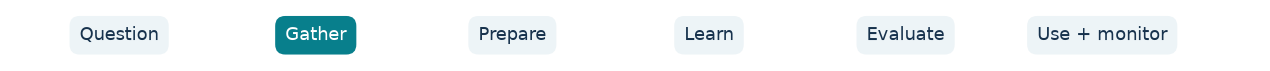

In [9]:
v.progress(1)

### Where do examples come from?
Rental transactions record trips. Calendar records identify working days and holidays. Weather observations describe conditions. Joining sources requires consistent dates and units.

**Question:** What would we miss if we collected examples only during summer? Both panels below use the training year.

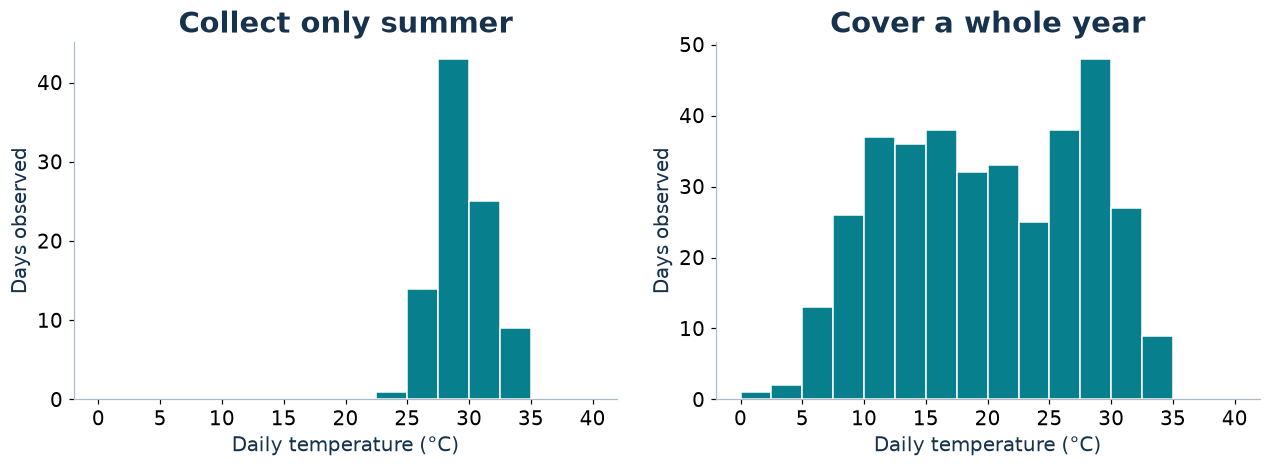

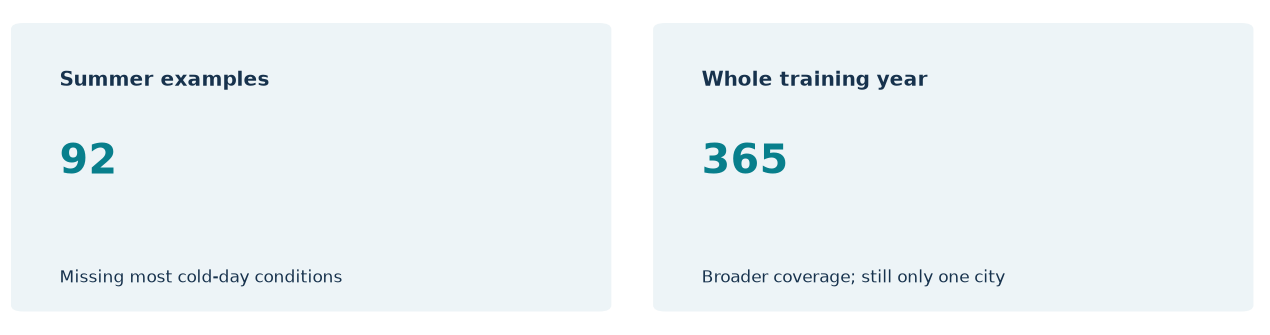

In [11]:
bikes.coverage(state)

### Clean with a reason

Look for a repeated record, a missing value, an impossible temperature, and inconsistent text. Decide what each one means before fixing it.

Unknown is different from zero. For a missing input, we can use a value learned from training data and keep a “was missing” flag. A missing answer is different: inventing rental counts would not give us trustworthy training labels.

**An unusual observation is not automatically an error.** A festival could produce a genuinely busy day. Check the source and the intended scope before deleting it.

Resolve duplicate identities before splitting. Reserve evaluation examples early. Learn imputation, scaling, feature choices, and other fitted transformations using training/validation data—not the final test.

**Takeaway:** Cleaning is a set of documented decisions about what the data means.

## 4 · Which clues should the model use?

**Question:** Choose from calendar information, weather, a record ID, and the day’s totals for casual and registered renters. Which clue is suspiciously helpful?

Feature **selection** chooses clues. Feature **engineering** creates a useful representation, such as a working-day flag from a calendar. The comparison below keeps the same learning method and changes the inputs.

Clue,Use?,Why
Calendar / working day,Yes,Available in advance
Weather conditions,For a conditions-based estimate,A forecast would need forecast weather
Record number,No meaningful reason here,An identifier is not an explanation
Registered + casual rentals,No — reveals the answer,Their sum is the target count


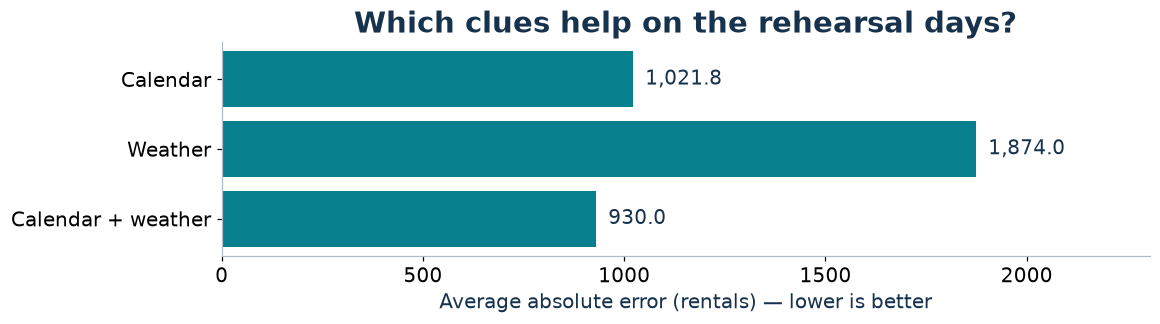

In [14]:
feature_results = bikes.feature_choices(state)

Registered rentals + casual rentals = total rentals. Supplying those subtotals would give the model the answer. This is **data leakage**: the score looks impressive, but the intended prediction cannot be made fairly.

The feature comparison uses validation days, not the final test. More clues do not automatically improve a model. A low linear correlation does not prove a clue is useless.

**Takeaway:** A useful clue must be legitimate for the question and available when making the prediction.

## 5 · Watch a model learn

We temporarily switch to **simulated bike demand** with one input so we can see the mechanism clearly. Dots are observations, the line is the model, and vertical gaps show prediction errors.

The model changes its starting level and slope to reduce a **loss**: a score for how wrong its training predictions are. Here the score averages **squared** gaps, so large errors count more strongly.

**Ask:** What should happen to the gaps as the line improves?

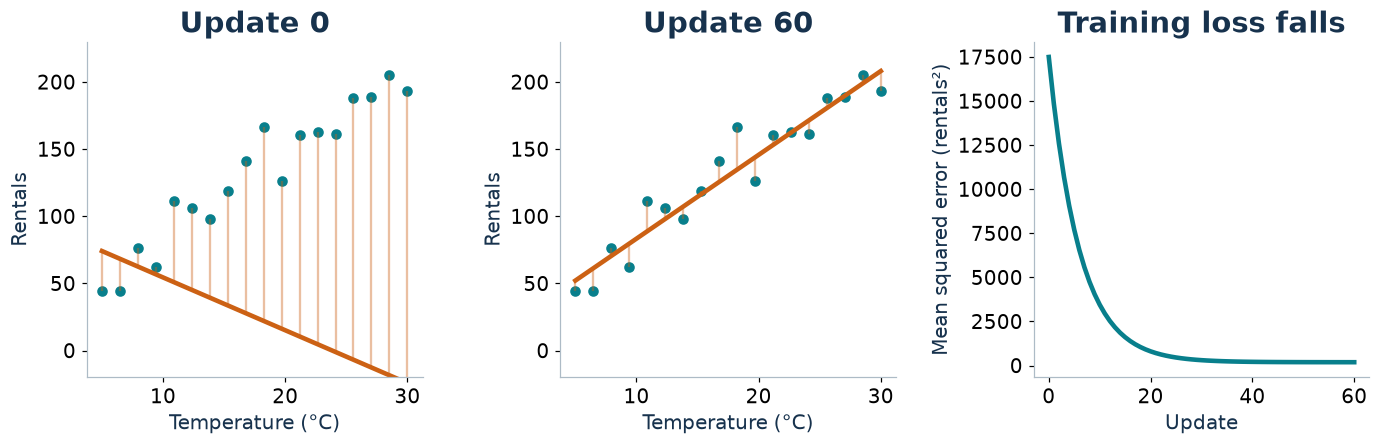

In [16]:
learning_history = bikes.loss_demo()

The updates here use gradient descent. We do not need its formula to understand the feedback loop: predict → measure error → adjust → repeat.

This illustrates one training method. A decision tree learns differently; not every model learns by moving a line. Also, smaller training loss does not guarantee good predictions on new situations.

### A model can be too simple or too flexible
The next example is also **simulated**. We fit the same observations three ways and reveal the same unseen rehearsal points for all three.

**Question:** Before looking at the errors, which model would you trust on a new day?

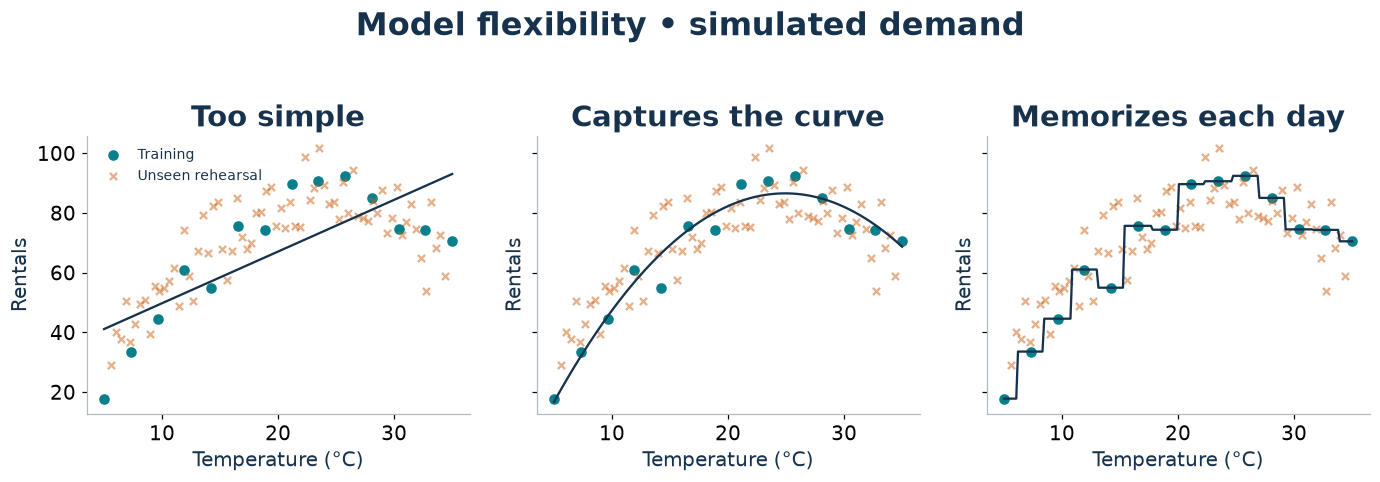

Model,Training MAE,Rehearsal MAE
Too simple,12.8,11.1
Captures the curve,3.8,7.5
Memorizes each day,0.0,9.2


In [17]:
complexity_scores = bikes.complexity()

**Underfitting:** the model misses an important pattern, so even training predictions are poor.

**Overfitting:** the model follows details and noise in the training observations, but those details do not repeat reliably.

The goal is useful performance on unfamiliar examples. A model is suitable for a problem and its data; no algorithm is always best.

Return to the **real bike data**. We now compare a baseline and several models on validation days.

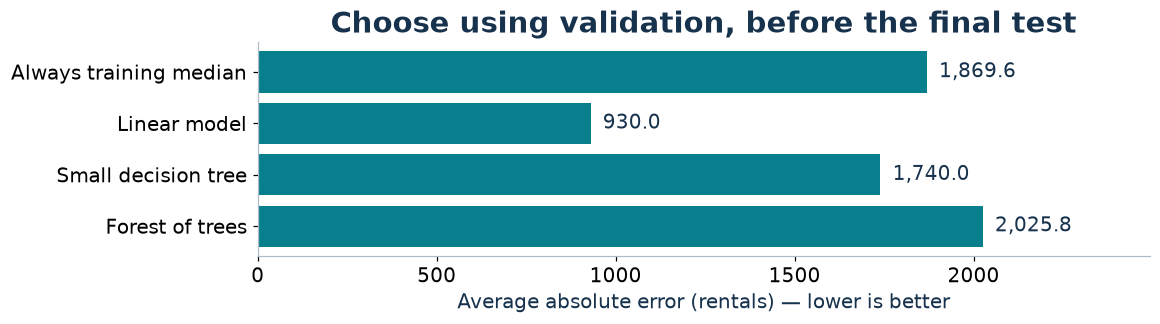

In [18]:
chosen_bike_model = bikes.select_model(state)

## 6 · Give the chosen model a fair final assessment


| Partition | Dates | Purpose |
|---|---|---|
| Training | January–December 2011 | Learn patterns and preprocessing. |
| Validation | January–June 2012 | Choose features and model settings. |
| Final test | July–December 2012 | Assess the chosen approach once. |

We now refit the chosen method on training + validation data, then open the later test period. We use chronological blocks because the question concerns unfamiliar later days. Growth and seasonal changes can make this harder than a random split.

**Mean absolute error (MAE)** is the average size of the mistakes, ignoring their direction. Unlike our squared-error training animation, MAE is expressed directly in rental counts. Compare it with always guessing the median from the development data.

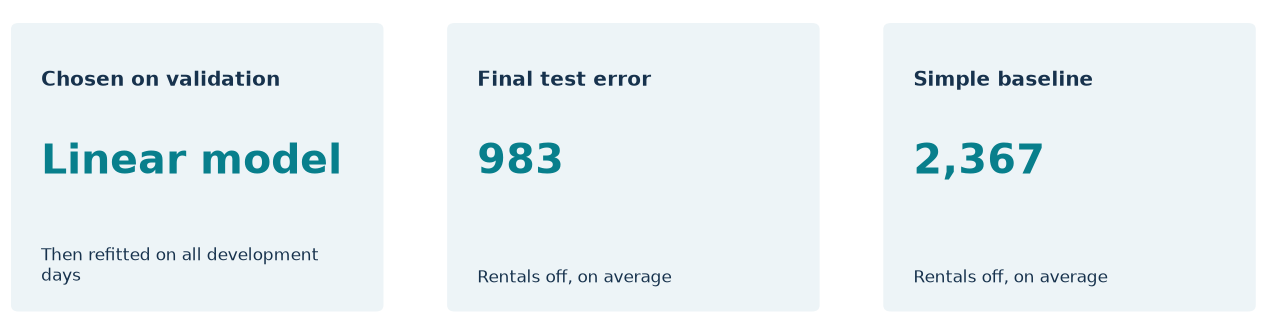

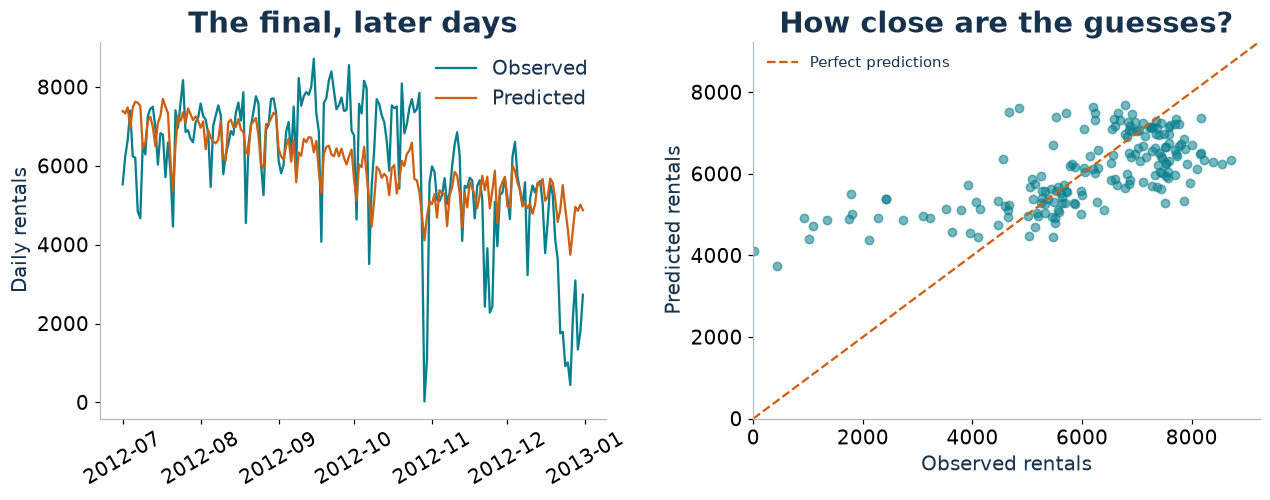

Date,Observed,Predicted,Absolute error
01 Jul 2012,5531,7391.0,1860.0
31 Jul 2012,7216,7142.0,74.0
30 Aug 2012,7713,7345.0,368.0
29 Sep 2012,8555,6238.0,2317.0


In [19]:
bike_test_mae = bikes.evaluate(state)

MAE summarizes many predictions. It is **not** a guarantee that every guess lies within that amount, and it is not an individual confidence interval. If the chosen method fails to beat a baseline, report that result and reconsider the approach using new development work—not repeated tuning on this test.

For classification, also ask **which kind of mistake matters**. This tiny spam-filter example is illustrative.

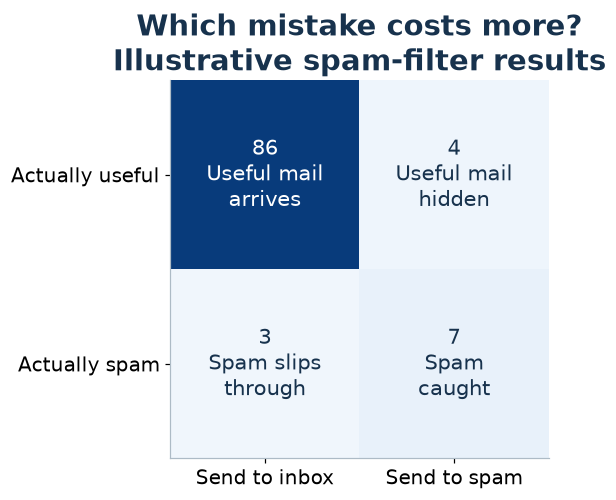

In [20]:
v.classification_errors()